
# Lab 7: Monte Carlo Markov Chain (MCMC)

* ## Angélica Vanegas C.C 1000290572

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona* un microestado $ x $ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $ x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema.
            Si la energía disminuye se acepta la nueva configuración $ x'$.
            Si aumenta, se debe generar un número aleatorio entre [0,1]. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)= e^{-E/(KT)}$ se rechaza $ x'$. De lo contrario se acepta la nueva configuración $ x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al criterio de finalización se debe terminar.


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Mostrar que la distribución canónica de la magnetización clásica es muy acertada (consultar).
3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

# Solución 1) Uso del método de Metrópolis

Tenemos un sistema de espines $si= ±1$ sometido a un campo magnético externo H. Asumiendo que los átomos son no interactuantes, la energía del sistema es:

$E=−μ_0H\sum_{i}si$.

Si tomamos las siguientes unidades: $μ_0=1$ y $k_B=1$, entonces

$E=−H\sum_{i}si$.


In [43]:
import numpy as np
import matplotlib.pyplot as plt

In [44]:
#@title Creación de la red 2D

#tomamos una red 10x10
L = 10
N = L*L

#asumimos valores para la temperatura y campo magnético

T = 2.0                # temperatura
H = 1.0                # campo magnético

# configuración inicial aleatoria
espines = np.random.choice([-1,1], size=(L,L)) #un arreglo con valores de spin aleatorios, arriba o abajo
espines

array([[-1,  1,  1, -1,  1,  1,  1, -1,  1,  1],
       [ 1, -1,  1, -1,  1,  1, -1, -1,  1, -1],
       [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 1,  1, -1,  1,  1,  1,  1, -1,  1,  1],
       [ 1, -1, -1, -1,  1, -1,  1,  1, -1, -1],
       [-1,  1,  1,  1,  1, -1, -1, -1, -1, -1],
       [-1,  1,  1, -1, -1, -1,  1, -1, -1, -1],
       [-1, -1,  1,  1,  1, -1, -1,  1, -1, -1],
       [ 1,  1, -1,  1,  1,  1, -1,  1, -1,  1],
       [ 1, -1,  1,  1, -1,  1, -1,  1,  1,  1]])

In [45]:
def energia(espines, H):   #definimos la función energía
    return -H*np.sum(espines)

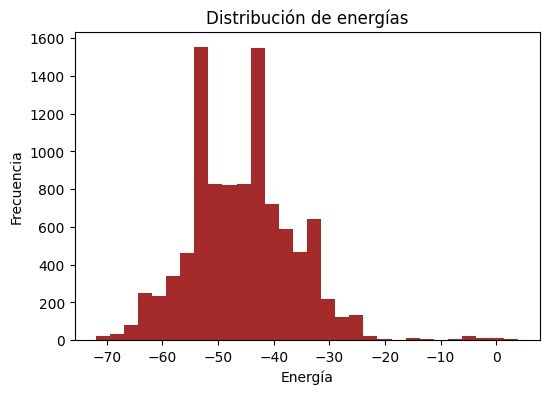

In [46]:
#@title Implementación del método, veamos como evoluciona el sistema

pasos = 10000


def EnergiayMagnetizacion(L, T, H, espines, pasos):

  E_hist = []   #almacena la energía y la magnetización en cada paso
  M_hist = []

  for paso in range(pasos):
    i = np.random.randint(0,L)   #visitamos aleatoriamente un átomos en la red
    j = np.random.randint(0,L)
    E_old = energia(espines, H)

    espines[i,j] *= -1           #modificamos el estado del espín en ese átomos
    E_new = energia(espines, H)  #calculamos nuevamente la energía

    dE = E_new - E_old           #calculamos la diferencia

    # criterio de aceptación de ese cambio que hicimos

    if dE <= 0:

          pass

    else:

      r = np.random.rand()

      if r > np.exp(-dE/T):     #probabilidad de Boltzmann de aceptar una configuración con mayor valor en la diferencia de energía
        espines[i,j] *= -1      #si es mayor a esa probabilidad entonces la rechazamos y volvemos a invertir el spin

    E_hist.append(energia(espines,H))
    M_hist.append(np.sum(espines))

  return E_hist, M_hist

E, M = EnergiayMagnetizacion(L, T, H, espines, pasos)

plt.figure(figsize=(6,4))
plt.hist(E, bins=30, color = "brown")
plt.xlabel("Energía")
plt.ylabel("Frecuencia")
plt.title("Distribución de energías")
plt.show()

# 2) Gráfica de la magnetización $ \langle M \rangle $ y 3) Análisis de la simulación

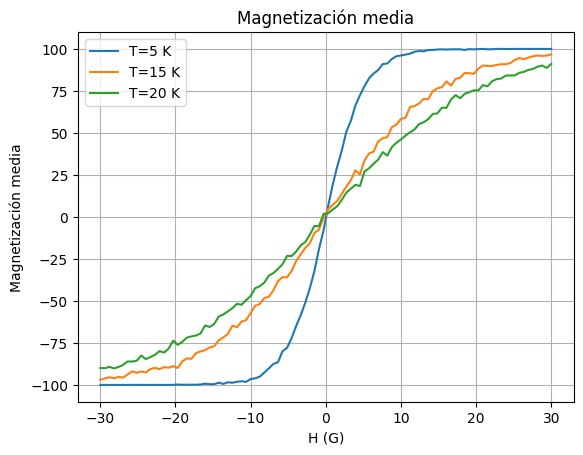

In [47]:
Hs = np.linspace(-30,30,100)
temperaturas = [5,15,20]

resultados = {}

for T in temperaturas: #Calculamos la magnetización media en función de la temperatura

    M_media = []

    for H in Hs:

        E, M = EnergiayMagnetizacion(L,T,H,espines, pasos)

        M_media.append(np.mean(M[pasos//2:]))

    resultados[T] = M_media

for T in temperaturas:         #Graficamos todos los valores
  plt.plot(Hs, resultados[T], label=f"T={T} K")

plt.title("Magnetización media")
plt.xlabel("H (G)")
plt.ylabel("Magnetización media")
plt.legend()
plt.grid()
plt.show()

# Comparemos con la distribución canónica de la magnetización clásica

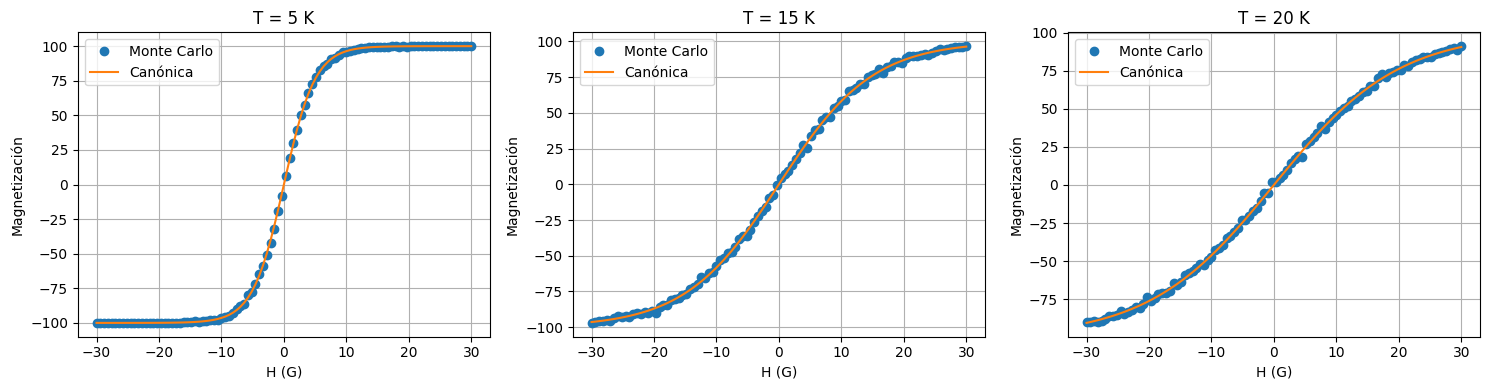

In [49]:
fig, axs = plt.subplots(1,3, figsize=(15,4))

for ax, T in zip(axs, temperaturas):

  M_MC = resultados[T]

  # Resultado teórico
  M_teorica = N*np.tanh(Hs/T)

  ax.plot(Hs, M_MC, 'o', label='Monte Carlo')
  ax.plot(Hs, M_teorica, '-', label='Canónica')

  ax.set_title(f"T = {T} K")
  ax.set_xlabel("H (G)")
  ax.set_ylabel("Magnetización")

  ax.grid(True)
  ax.legend()

plt.tight_layout()
plt.show()

https://en.wikipedia.org/wiki/Ising_model

Aunque el sistema está definido en una red bidimensional, los espines no interactúan, por lo que el problema se reduce a un conjunto de espines independientes. Por esta razón, el resultado analítico coincide con el del paramagneto ideal y no depende de la dimensionalidad del sistema en este caso, aunque en el documento de Wikipedia explican otras dimensiones.

Las gráficas obtenidas mediante Monte Carlo siguen la tendencia de la predicción teórica, la magnetización al aumentar la temperatura la curva se vuelve más suave debido a las fluctuaciones térmicas. Este comportamiento concuerda con la expresión $⟨M⟩=Nμtanh(μH/k
BT)$, derivada en Huang (Statistical Mechanics, 2nd ed.)

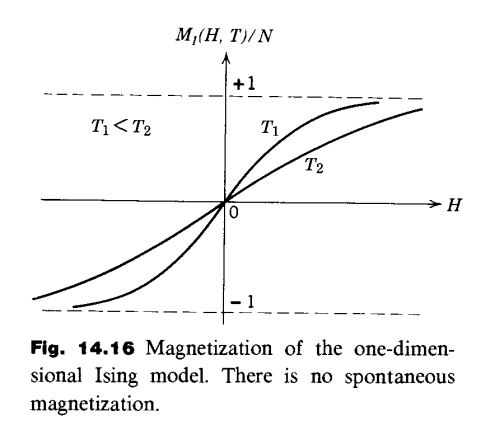

Nota: 4.5 (entrega tarde)

* En la magnetización haces kB = 1, magneton de Bhor 1..., pero al final debe recuperarse el valor en el MKS. 

* .. se dejó llevar con el error en el enunciado... 